In [18]:
import os
import json
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [60]:
def get_min_losses(results_path):
    with open(results_path, "r") as f:
        data = json.load(f)
    result = {}
    for split in ["train", "val"]:
        result[split] = {}
        for loss_type in ["image", "timepoint", "weighted_loss"]:
            losses = data["losses"][split].get(loss_type, [])
            result[split][loss_type] = min(losses) if losses else None
    return result

def collect_all_losses(studies, results_base="results", only_best=False):
    all_losses = defaultdict(lambda: defaultdict(dict))

    for study in studies:
        study_path = os.path.join(results_base, study)
        if not os.path.isdir(study_path):
            continue

        experiment_dirs = sorted(os.listdir(study_path))

        for experiment in experiment_dirs:
            experiment_path = os.path.join(study_path, experiment)
            if not os.path.isdir(experiment_path):
                continue

            model_dirs = ["_best_model"] if only_best else [d for d in os.listdir(experiment_path) if d != "_best_model"]

            for model_dir in model_dirs:
                model_path = os.path.join(experiment_path, model_dir)
                dataset_path = os.path.join(model_path, os.listdir(model_path)[0])
                results_path = os.path.join(dataset_path, "results.json")
                if not os.path.isfile(results_path):
                    continue

                min_losses = get_min_losses(results_path)
                all_losses[study][experiment][model_dir] = min_losses

    return all_losses

def plot_loss_comparison(loss_data, loss_type="image", figsize=(10, 6), save_path=None):
    records = []

    for study, experiments in loss_data.items():
        for experiment, models in experiments.items():
            for model_name, losses in models.items():
                for split in ["train", "val"]:
                    loss_value = losses[split].get(loss_type)
                    if loss_value is not None:
                        records.append({
                            "Study": study,
                            "Experiment": experiment,
                            "Model": model_name,
                            "Split": "Train" if split == "train" else "Validation",
                            "Loss": loss_value
                        })

    df = pd.DataFrame(records)

    sns.set(style="white", font_scale=1.5)
    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=df,
        x="Experiment",
        y="Loss",
        hue="Split",
        dodge=True,
        palette="muted"
    )
    sns.despine()
    ax.grid(False)
    ax.tick_params(axis='y', labelsize=24)
    plt.legend('',frameon=False)
    plt.tight_layout()


    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()
    else:
        plt.show()

def load_accuracy_data(json_paths):
    records = []

    for path in json_paths:
        if not os.path.isfile(path):
            print(f"Warning: File not found - {path}")
            continue

        with open(path, "r") as f:
            data = json.load(f)

        study_name = data.get("study_name", os.path.basename(path))
        for result in data["model_dataset_results"]:
            model = result["model_name"]
            dataset = result["dataset_name"]
            correct = result["total_correct"]
            incorrect = result["total_incorrect"]
            total = correct + incorrect
            accuracy = correct / total if total > 0 else 0.0

            records.append({
                "Study": study_name,
                "Model": model,
                "Dataset": dataset,
                "Accuracy": accuracy
            })

    return pd.DataFrame(records)

def plot_accuracy_bars(df, figsize=(10, 6), save_path=None):
    sns.set(style="white", font_scale=1.5)
    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=df,
        x="Model",
        y="Accuracy",
        hue="Split", 
        dodge=True,
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy", fontsize=16)
    ax.set_xlabel("Model", fontsize=16)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=24)
    ax.grid(False)
    plt.legend('',frameon=False)
    sns.despine()
    
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

In [20]:
studies = ["ae-architecture-gastruloid", "cae-architecture-gastruloid", "neuralop-latentdim-gastruloid-16"]
loss_data = collect_all_losses(studies, only_best=True)
for study in list(loss_data.keys()):
    loss_data[study] = {
        experiment: models
        for experiment, models in loss_data[study].items()
        if "small" not in experiment
    }
model_type = "gastruloid-all"

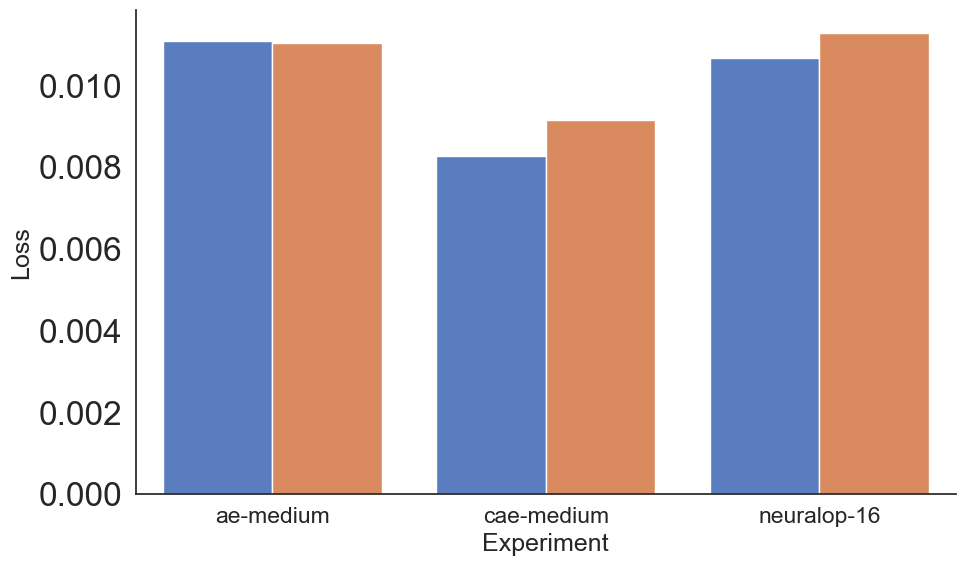

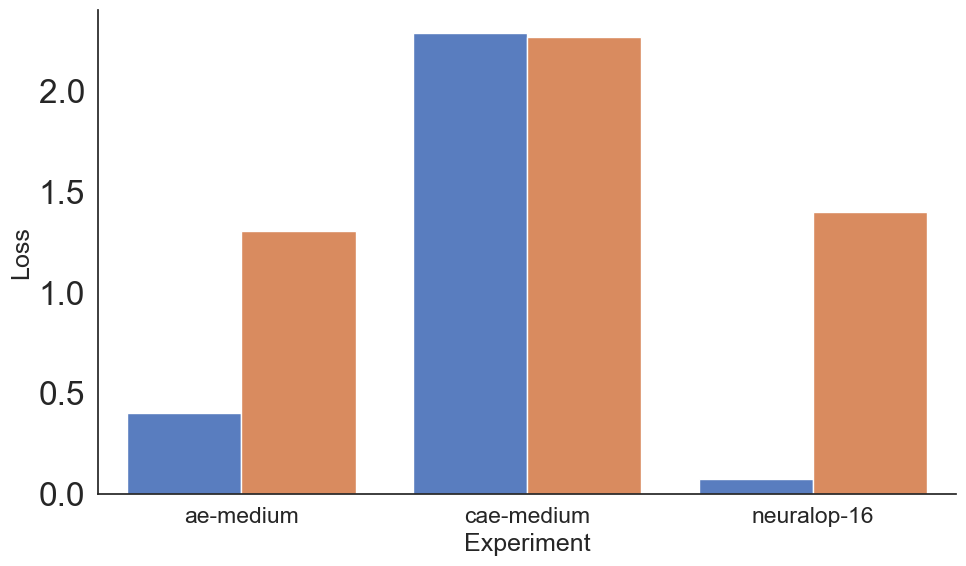

In [21]:
plot_loss_comparison(loss_data, loss_type="image", save_path=f"figures/plots/{model_type}_image_loss.png")
plot_loss_comparison(loss_data, loss_type="timepoint", save_path=f"figures/plots/{model_type}_timepoint_loss.png")

In [34]:
studies = ["ae-architecture-ARCADE", "cae-architecture-ARCADE", "neuralop-architecture-ARCADE"]
loss_data = collect_all_losses(studies, only_best=True)
for study in list(loss_data.keys()):
    loss_data[study] = {
        experiment: models
        for experiment, models in loss_data[study].items()
        if "small" in experiment
    }
model_type = "ARCADE-all"

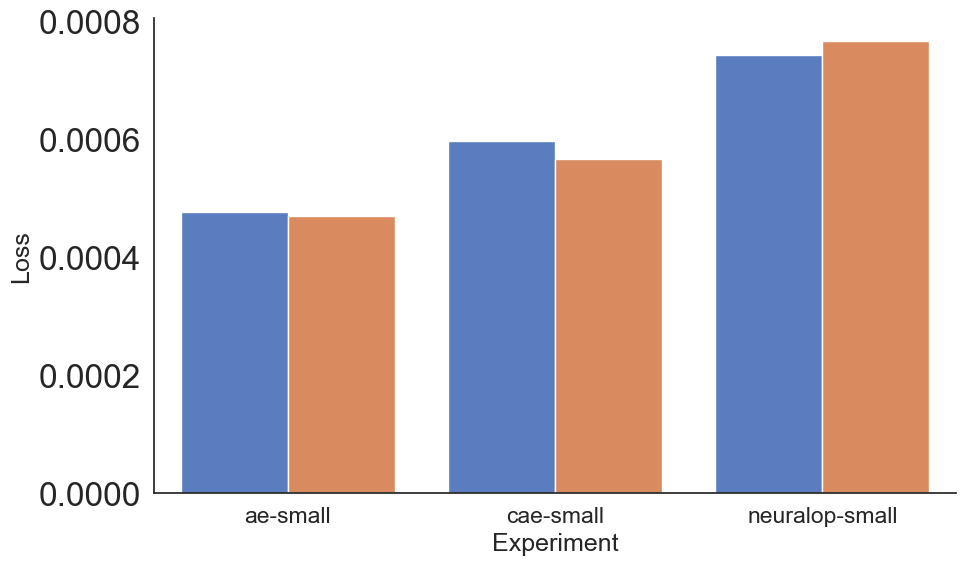

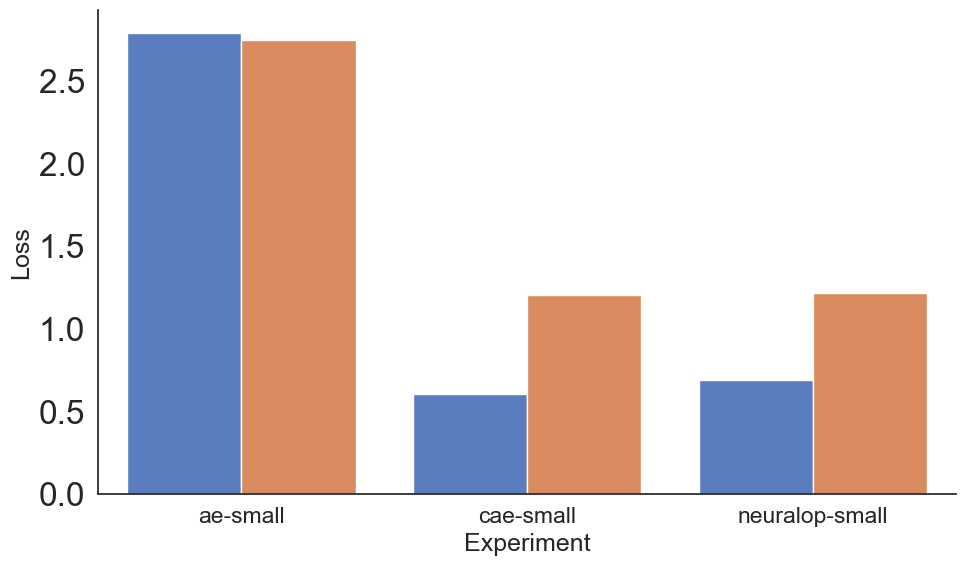

In [35]:
plot_loss_comparison(loss_data, loss_type="image", save_path=f"figures/plots/{model_type}_image_loss.png")
plot_loss_comparison(loss_data, loss_type="timepoint", save_path=f"figures/plots/{model_type}_timepoint_loss.png")

In [24]:
studies = ["neuralop-latentdim-gastruloid"]
loss_data = collect_all_losses(studies, only_best=True)
model_type = "neuralop"

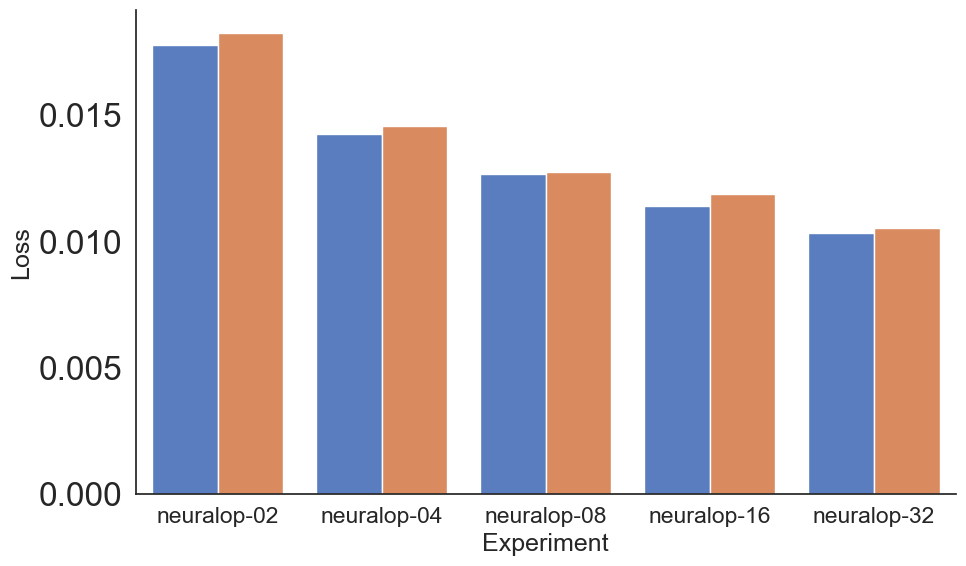

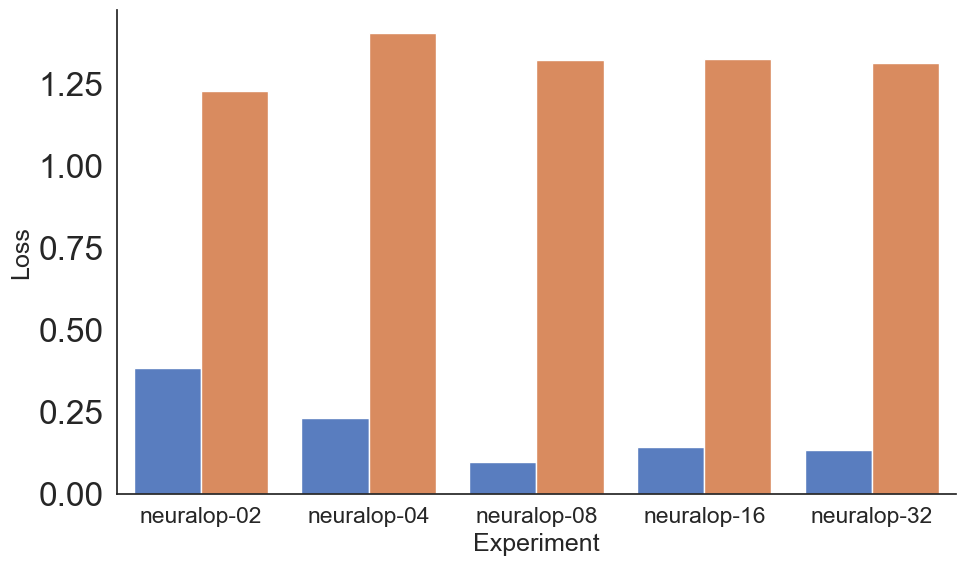

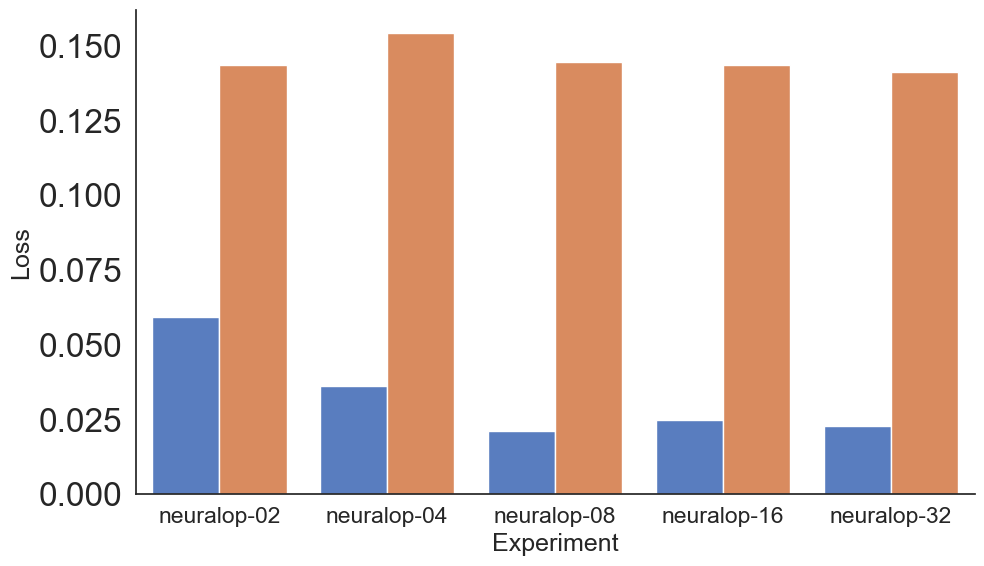

In [25]:
plot_loss_comparison(loss_data, loss_type="image", save_path=f"figures/plots/{model_type}_image_loss.png")
plot_loss_comparison(loss_data, loss_type="timepoint", save_path=f"figures/plots/{model_type}_timepoint_loss.png")
plot_loss_comparison(loss_data, loss_type="weighted_loss", save_path=f"figures/plots/{model_type}_weighted_loss.png")

In [56]:
json_files = [
    "results_downstream/ae-architecture-gastruloid_classification_results.json",
    "results_downstream/cae-architecture-gastruloid_classification_results.json",
    "results_downstream/neuralop-latentdim-gastruloid-16_classification_results.json"
]

df = load_accuracy_data(json_files)
df_filtered = df[~df["Model"].str.contains("medium", case=False)]



df = pd.DataFrame([
    {"Model": "model-a", "Split": "Train", "Accuracy": 0.70},
    {"Model": "model-a", "Split": "Test",  "Accuracy": 0.67},
    {"Model": "model-b", "Split": "Train", "Accuracy": 0.76},
    {"Model": "model-b", "Split": "Test",  "Accuracy": 0.70},
    {"Model": "model-c", "Split": "Train", "Accuracy": 0.84},
    {"Model": "model-c", "Split": "Test",  "Accuracy": 0.74},
])


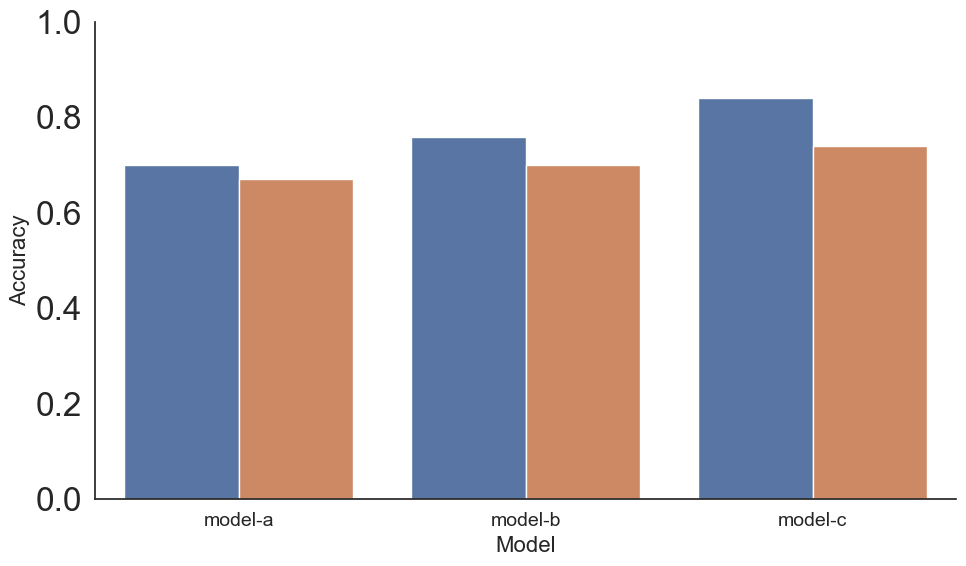

In [61]:
plot_accuracy_bars(df)